In [ ]:
!pip install timm transformers datasets accelerate --quiet

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 324, in run
    session = self.get_default_session(options)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 71, in get_default_session
    self._session = self.enter_context(self._build_session(options))
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 100, in _build_session
    session = PipSession(
              ^^^^^^^^^

In [ ]:
!pip install shap --quiet

### What is SHAP?

SHAP (SHapley Additive exPlanations) is a game-theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory.

For an image classification model, SHAP can tell us which parts (pixels or superpixels) of an input image contributed most positively or negatively to a specific class prediction. This helps in understanding the model's decision-making process, identifying potential biases, and building trust in the model.

To apply SHAP to our hybrid model, we'll need to:
1.  **Define a prediction function**: This function will take raw images as input, pass them through the `HybridFeatureExtractor`, and then use the trained XGBoost model to get class probabilities.
2.  **Select background data**: SHAP's `KernelExplainer` needs a representative background dataset to understand the typical feature values and compute baselines.
3.  **Select samples for explanation**: We'll pick a few images from the test set to visualize their SHAP explanations.

In [1]:
import zipfile
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
zip_path="/content/drive/MyDrive/Research_project/TrashNeXt Dataset.zip"
extract_path = "/content"


In [3]:
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)
!ls {extract_path}

Dataset extracted to: /content
 drive	 __MACOSX   sample_data  'TrashNeXt Dataset'


In [4]:
import os
from PIL import Image
from tqdm import tqdm

def is_corrupted_image(file_path):
    """Check if an image file is corrupted."""
    try:
        with Image.open(file_path) as img:
            img.verify()  # Verify integrity
        return False
    except (IOError, SyntaxError, Image.DecompressionBombError):
        return True

def remove_corrupted_images(dataset_path):
    """Scan and remove corrupted images + hidden macOS files."""
    corrupted_count = 0
    total_images = 0

    for root, _, files in os.walk(dataset_path):
        for file in tqdm(files, desc=f"Scanning {os.path.basename(root)}"):

            # Skip hidden files (.DS_Store, ._files)
            if file.startswith("."):
                file_path = os.path.join(root, file)
                try:
                    os.remove(file_path)
                    corrupted_count += 1
                    print(f"Removed hidden file: {file_path}")
                except:
                    pass
                continue

            # Check only image formats
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                total_images += 1
                file_path = os.path.join(root, file)
                if is_corrupted_image(file_path):
                    try:
                        os.remove(file_path)
                        corrupted_count += 1
                        print(f"Removed corrupted image: {file_path}")
                    except Exception as e:
                        print(f"Error removing {file_path}: {e}")

    print("\n✅ Scan completed!")
    print(f"📷 Total images scanned: {total_images}")
    print(f"🗑️ Corrupted/hidden files removed: {corrupted_count}")

# Run the cleaner
dataset_path = '/content/dataset'  # Your dataset path
remove_corrupted_images(dataset_path)


Scanning dataset: 100%|██████████| 1/1 [00:00<00:00, 3070.50it/s]


Removed hidden file: /content/dataset/.DS_Store


Scanning Valid: 100%|██████████| 1/1 [00:00<00:00, 7319.90it/s]


Removed hidden file: /content/dataset/Valid/.DS_Store


Scanning Test: 100%|██████████| 1/1 [00:00<00:00, 6875.91it/s]


Removed hidden file: /content/dataset/Test/.DS_Store


Scanning Train: 100%|██████████| 1/1 [00:00<00:00, 6721.64it/s]


Removed hidden file: /content/dataset/Train/.DS_Store


Scanning organic: 100%|██████████| 2391/2391 [00:01<00:00, 1878.73it/s]


✅ Scan completed!
📷 Total images scanned: 23625
🗑️ Corrupted/hidden files removed: 4


In [5]:
from PIL import Image
import os

def remove_truncated_images(dataset_path):
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                try:
                    img_path = os.path.join(root, file)
                    img = Image.open(img_path)
                    img.verify()
                except Exception as e:
                    print(f"Removing corrupted/truncated: {img_path}")
                    os.remove(img_path)

remove_truncated_images("/content/dataset")


In [6]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [7]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import timm
import numpy as np
import os
from tqdm import tqdm

In [8]:
class HybridFeatureExtractor(nn.Module):
    def __init__(self):
        super(HybridFeatureExtractor, self).__init__()
        # EfficientNetV2 feature extractor
        self.efficientnet = models.efficientnet_v2_s(weights="IMAGENET1K_V1")
        self.efficientnet.classifier = nn.Identity()

        # LeViT feature extractor
        self.levit = timm.create_model('levit_256', pretrained=True)

        # Replace classification heads with identity
        self.levit.head = nn.Identity()
        if hasattr(self.levit, 'dist_head'):
            self.levit.dist_head = nn.Identity()

        # ✅ Force LeViT to skip forward_head completely
        def forward_override(x):
            # run backbone (patch embedding + transformer encoder + pooling)
            x = self.levit.forward_features(x)   # [B, N, D]
            # take CLS token only (LeViT uses CLS for classification)
            x = x[:, 0, :]                       # [B, D]
            return x
        self.levit.forward = forward_override

    def forward(self, x):
        # Resize for each model
        x_eff = transforms.functional.resize(x, (300, 300))
        x_levit = transforms.functional.resize(x, (224, 224))

        with torch.no_grad():
            features_eff = self.efficientnet(x_eff)  # [B, 1280]
            features_levit = self.levit(x_levit)     # [B, 512]

        return torch.cat((features_eff, features_levit), dim=1)


In [9]:
def extract_features(data_loader, model, device):
    all_features = []
    all_labels = []

    model.eval()
    for images, labels in tqdm(data_loader, desc="Extracting features"):
        images = images.to(device)
        features = model(images)
        all_features.append(features.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    return np.concatenate(all_features), np.concatenate(all_labels)

In [10]:
if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --- Data Loading ---
    # ❗️ IMPORTANT: Update these paths to your dataset location in Google Drive
    train_dir = "/content/dataset/Train" # Corrected path
    valid_dir = "/content/dataset/Valid" # Corrected path

    data_transforms = transforms.Compose([
        transforms.Resize((256, 256)), # Initial resize
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
    valid_dataset = datasets.ImageFolder(valid_dir, transform=data_transforms)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

    # --- Initialize model and extract ---
    feature_extractor = HybridFeatureExtractor().to(device)

    X_train, y_train = extract_features(train_loader, feature_extractor, device)
    X_valid, y_valid = extract_features(valid_loader, feature_extractor, device)

    print(f"Training features shape: {X_train.shape}")
    print(f"Validation features shape: {X_valid.shape}")

    # Save features for the next stage
    np.save('X_train.npy', X_train)
    np.save('y_train.npy', y_train)
    np.save('X_valid.npy', X_valid)
    np.save('y_valid.npy', y_valid)
    print("✅ Features saved!")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:01<00:00, 72.9MB/s]


model.safetensors:   0%|          | 0.00/75.9M [00:00<?, ?B/s]

Extracting features:   0%|          | 0/591 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Extracting features: 100%|██████████| 74/74 [00:49<00:00,  1.50it/s]

Training features shape: (18898, 1792)
Validation features shape: (2363, 1792)
✅ Features saved!


In [11]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt

# --- Load extracted features ---
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_valid = np.load("X_valid.npy")
y_valid = np.load("y_valid.npy")

In [12]:
# Create DMatrix (optimized format for XGBoost)
dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)

# --- XGBoost Parameters ---
params = {
    'objective': 'multi:softprob',   # multi-class classification
    'num_class': len(np.unique(y_train)),
    'eval_metric': 'mlogloss',
    'learning_rate': 0.25858285509781914,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

In [13]:
# --- Training with evaluation ---
num_rounds = 236   # total boosting rounds (like epochs)
evals = [(dtrain, 'train'), (dvalid, 'valid')]
evals_result = {}

model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_rounds,
    evals=evals,
    evals_result=evals_result,
    verbose_eval=1
)

# --- Collect metrics ---
train_logloss = evals_result['train']['mlogloss']
valid_logloss = evals_result['valid']['mlogloss']

# Accuracy at each round
train_acc, valid_acc = [], []
for i in range(1, num_rounds+1):
    y_train_pred = np.argmax(model.predict(dtrain, iteration_range=(0, i)), axis=1)
    y_valid_pred = np.argmax(model.predict(dvalid, iteration_range=(0, i)), axis=1)
    train_acc.append(accuracy_score(y_train, y_train_pred))
    valid_acc.append(accuracy_score(y_valid, y_valid_pred))

    print(f"Round {i}/{num_rounds} "
          f"| Train Loss: {train_logloss[i-1]:.4f}, Train Acc: {train_acc[-1]:.4f} "
          f"| Val Loss: {valid_logloss[i-1]:.4f}, Val Acc: {valid_acc[-1]:.4f}")


[0]	train-mlogloss:1.58924	valid-mlogloss:1.63234
[1]	train-mlogloss:1.29804	valid-mlogloss:1.37158
[2]	train-mlogloss:1.09523	valid-mlogloss:1.18472
[3]	train-mlogloss:0.94650	valid-mlogloss:1.05236
[4]	train-mlogloss:0.82781	valid-mlogloss:0.94324
[5]	train-mlogloss:0.73539	valid-mlogloss:0.86125
[6]	train-mlogloss:0.65624	valid-mlogloss:0.78974
[7]	train-mlogloss:0.59229	valid-mlogloss:0.73269
[8]	train-mlogloss:0.53713	valid-mlogloss:0.68551
[9]	train-mlogloss:0.48920	valid-mlogloss:0.64557
[10]	train-mlogloss:0.44849	valid-mlogloss:0.61038
[11]	train-mlogloss:0.41198	valid-mlogloss:0.58114
[12]	train-mlogloss:0.37944	valid-mlogloss:0.55735
[13]	train-mlogloss:0.35117	valid-mlogloss:0.53672
[14]	train-mlogloss:0.32627	valid-mlogloss:0.51778
[15]	train-mlogloss:0.30356	valid-mlogloss:0.50199
[16]	train-mlogloss:0.28295	valid-mlogloss:0.48606
[17]	train-mlogloss:0.26474	valid-mlogloss:0.47371
[18]	train-mlogloss:0.24836	valid-mlogloss:0.46262
[19]	train-mlogloss:0.23230	valid-mloglos

In [14]:
import shap

# Use a subset of training data as background (for speed)
background_size = min(500, X_train.shape[0])
background = X_train[:background_size]

# Create TreeExplainer for the trained XGBoost model
explainer = shap.TreeExplainer(model)

# Pick a small subset of validation data for explanation (to save time)
sample_size = min(200, X_valid.shape[0])
X_valid_sample = X_valid[:sample_size]

# Compute SHAP values
# For multi-class XGBoost, this often returns a list: one array per class
shap_values = explainer.shap_values(X_valid_sample)

print("Type of shap_values:", type(shap_values))

Type of shap_values: <class 'numpy.ndarray'>


In [15]:
print("shap_values.shape:", shap_values.shape)
print("X_valid_sample.shape:", X_valid_sample.shape)

shap_values.shape: (200, 1792, 9)
X_valid_sample.shape: (200, 1792)


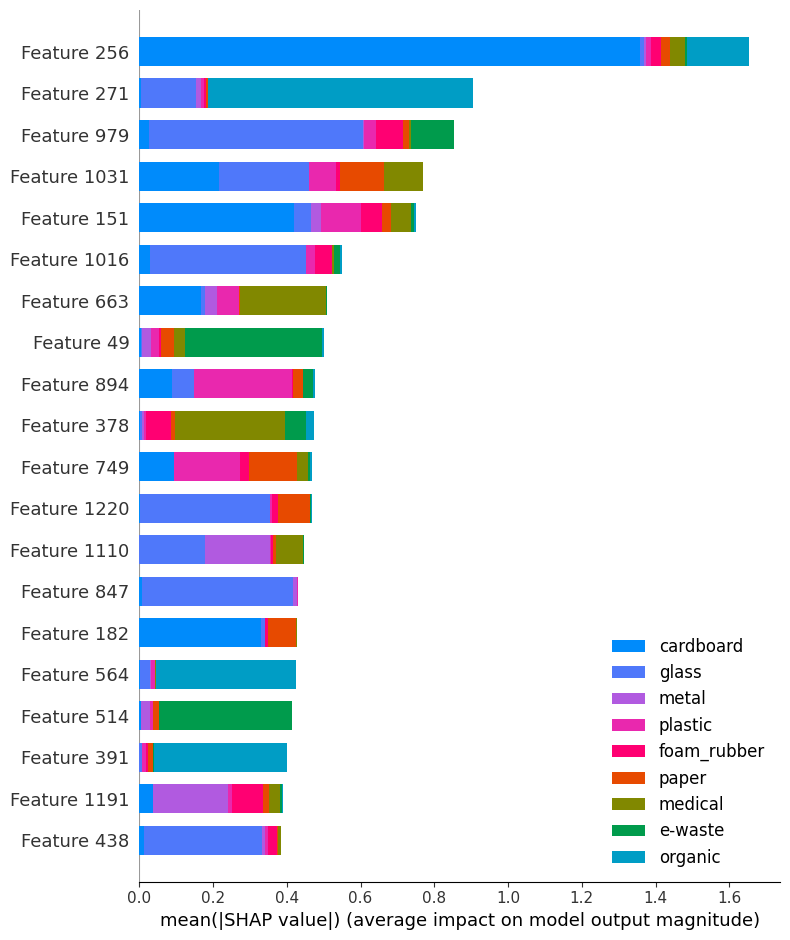

In [16]:
# If shap_values is a list (one per class), choose the class you care about most
# Example: class 0
if isinstance(shap_values, list):
    shap_values_for_plot = shap_values[0]
else:
    shap_values_for_plot = shap_values

# Get class names for plotting (assuming train_dataset is available from previous cells)
class_names = train_dataset.classes

# Wrap as Explanation for newer SHAP versions (optional but cleaner)
shap.summary_plot(shap_values_for_plot, X_valid_sample, plot_type="bar", class_names=class_names)

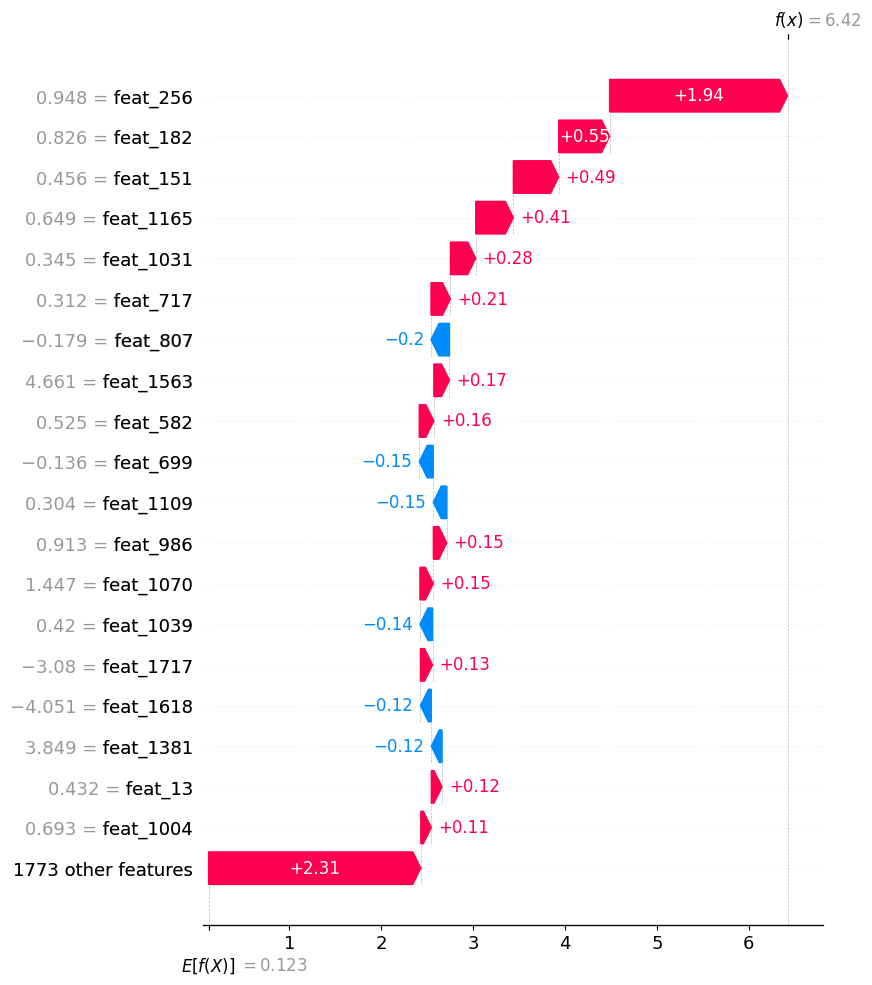

In [17]:
# Choose one index from the sample
idx = 0

# Get model prediction probabilities for this subset to determine the predicted class
dvalid_sample = xgb.DMatrix(X_valid_sample)
probs = model.predict(dvalid_sample)  # shape: (n_samples, num_classes)
pred_class = np.argmax(probs[idx])

if isinstance(shap_values, list):
    # shap_values[class][sample, feature]
    shap_values_single = shap_values[pred_class][idx]
else:
    # For some SHAP versions shap_values is (n_samples, n_features, n_classes)
    # We need to select the shap values for the predicted class for this sample
    shap_values_single = shap_values[idx, :, pred_class]

# Build a SHAP Explanation object for nice plots (optional)
exp = shap.Explanation(
    values=shap_values_single,
    base_values=explainer.expected_value[pred_class] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    data=X_valid_sample[idx],
    feature_names=[f"feat_{i}" for i in range(X_valid_sample.shape[1])]
)

shap.plots.waterfall(exp, max_display=20)

In [18]:


import time

# --- Define the path to your test data ---
test_dir = "/content/dataset/Test"

# --- Create the test dataset and dataloader ---
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- Extract and save features for the test set ---
print("Extracting features from the test set...")
start_time = time.time()

X_test, y_test = extract_features(test_loader, feature_extractor, device)

end_time = time.time()
print(f"Feature extraction for test set took: {end_time - start_time:.2f} seconds")

print(f"Test features shape: {X_test.shape}")

# --- Save features for later use ---
np.save('X_test.npy', X_test)
np.save('y_test.npy', y_test)
print("✅ Test features saved!")

Extracting features from the test set...


Extracting features:   1%|▏         | 1/74 [00:00<00:47,  1.52it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Extracting features: 100%|██████████| 74/74 [00:48<00:00,  1.54it/s]

Feature extraction for test set took: 48.06 seconds
Test features shape: (2364, 1792)
✅ Test features saved!


In [19]:


import numpy as np
import time
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, log_loss

# --- Load the test set features ---
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

# --- Create the DMatrix for the test set ---
dtest = xgb.DMatrix(X_test, label=y_test)

# --- Helper function to calculate TPR and FPR from a confusion matrix ---
def calculate_tpr_fpr(cm):
    """Calculates macro-average TPR and FPR for a multi-class confusion matrix."""
    num_classes = cm.shape[0]
    tpr_list = []
    fpr_list = []

    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)

        # True Positive Rate (Recall)
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.
        tpr_list.append(tpr)

        # False Positive Rate
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.
        fpr_list.append(fpr)

    return np.mean(tpr_list), np.mean(fpr_list)


# ===================================================================
#                       PERFORMANCE EVALUATION
# ===================================================================

# Get the class names from the dataset folder structure
class_names = train_dataset.classes

# --- Get predictions (probabilities and final labels) ---
# Training Set
train_start_time = time.time()
y_train_pred_proba = model.predict(dtrain)
train_pred_time = time.time() - train_start_time
y_train_pred = np.argmax(y_train_pred_proba, axis=1)

# Validation Set
valid_start_time = time.time()
y_valid_pred_proba = model.predict(dvalid)
valid_pred_time = time.time() - valid_start_time
y_valid_pred = np.argmax(y_valid_pred_proba, axis=1)

# Testing Set
test_start_time = time.time()
y_test_pred_proba = model.predict(dtest)
test_pred_time = time.time() - test_start_time
y_test_pred = np.argmax(y_test_pred_proba, axis=1)


# --- Calculate Metrics ---
# Training
report_train = classification_report(y_train, y_train_pred, target_names=class_names, output_dict=True)
cm_train = confusion_matrix(y_train, y_train_pred)
tpr_train, fpr_train = calculate_tpr_fpr(cm_train)
loss_train = evals_result['train']['mlogloss'][-1] # Get final loss from training history

# Validation
report_valid = classification_report(y_valid, y_valid_pred, target_names=class_names, output_dict=True)
cm_valid = confusion_matrix(y_valid, y_valid_pred)
tpr_valid, fpr_valid = calculate_tpr_fpr(cm_valid)
loss_valid = evals_result['valid']['mlogloss'][-1] # Get final loss from training history

# Testing
report_test = classification_report(y_test, y_test_pred, target_names=class_names, output_dict=True)
cm_test = confusion_matrix(y_test, y_test_pred)
tpr_test, fpr_test = calculate_tpr_fpr(cm_test)
loss_test = log_loss(y_test, y_test_pred_proba) # Calculate test loss manually
auroc_test = roc_auc_score(y_test, y_test_pred_proba, multi_class='ovr', average='weighted')


# --- Print Final Reports ---

print("="*50)
print("          TRAINING SET METRICS")
print("="*50)
print(f"Accuracy:          {report_train['accuracy']:.4f}")
print(f"Weighted Precision:  {report_train['weighted avg']['precision']:.4f}")
print(f"Weighted Recall/TPR: {report_train['weighted avg']['recall']:.4f}")
print(f"Weighted F1-Score:   {report_train['weighted avg']['f1-score']:.4f}")
print(f"Macro Avg FPR:       {fpr_train:.4f}")
print(f"Final Loss:          {loss_train:.4f}")
# Note: Training time is the time for the entire xgb.train() call
print(f"Inference Time:      {train_pred_time:.4f} seconds\n")


print("="*50)
print("         VALIDATION SET METRICS")
print("="*50)
print(f"Accuracy:          {report_valid['accuracy']:.4f}")
print(f"Weighted Precision:  {report_valid['weighted avg']['precision']:.4f}")
print(f"Weighted Recall/TPR: {report_valid['weighted avg']['recall']:.4f}")
print(f"Weighted F1-Score:   {report_valid['weighted avg']['f1-score']:.4f}")
print(f"Macro Avg FPR:       {fpr_valid:.4f}")
print(f"Final Loss:          {loss_valid:.4f}")
print(f"Validation Time:     {valid_pred_time:.4f} seconds\n")


print("="*50)
print("           TESTING SET METRICS")
print("="*50)
print(f"Accuracy:          {report_test['accuracy']:.4f}")
print(f"Weighted Precision:  {report_test['weighted avg']['precision']:.4f}")
print(f"Weighted Recall/TPR: {report_test['weighted avg']['recall']:.4f}")
print(f"Weighted F1-Score:   {report_test['weighted avg']['f1-score']:.4f}")
print(f"Macro Avg FPR:       {fpr_test:.4f}")
print(f"Weighted AUROC:      {auroc_test:.4f}")
print(f"Final Loss:          {loss_test:.4f}")
print(f"Testing Time:        {test_pred_time:.4f} seconds\n")

          TRAINING SET METRICS
Accuracy:          0.9999
Weighted Precision:  0.9999
Weighted Recall/TPR: 0.9999
Weighted F1-Score:   0.9999
Macro Avg FPR:       0.0000
Final Loss:          0.0013
Inference Time:      0.0024 seconds

         VALIDATION SET METRICS
Accuracy:          0.9111
Weighted Precision:  0.9115
Weighted Recall/TPR: 0.9111
Weighted F1-Score:   0.9111
Macro Avg FPR:       0.0111
Final Loss:          0.3071
Validation Time:     0.0005 seconds

           TESTING SET METRICS
Accuracy:          0.8981
Weighted Precision:  0.8982
Weighted Recall/TPR: 0.8981
Weighted F1-Score:   0.8980
Macro Avg FPR:       0.0128
Weighted AUROC:      0.9926
Final Loss:          0.3450
Testing Time:        0.0892 seconds



Shape of background images for SHAP: (50, 256, 256, 3)
Shape of explanation images for SHAP: (5, 256, 256, 3)
Calculating SHAP values... This may take a while.


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 6it [00:31,  6.38s/it]


SHAP values calculated.

Visualizing SHAP explanations:
Explanation for test sample 1 (True Class: e-waste)
Predicted Class: e-waste


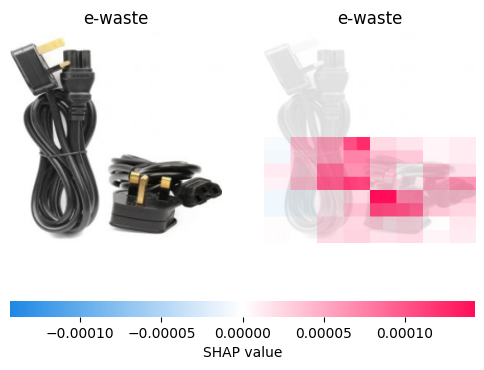

Explanation for test sample 2 (True Class: medical)
Predicted Class: medical


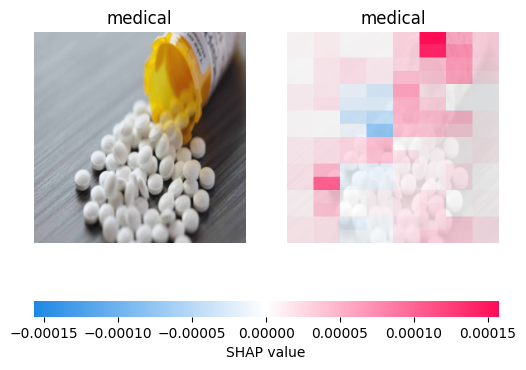

Explanation for test sample 3 (True Class: metal)
Predicted Class: foam_rubber


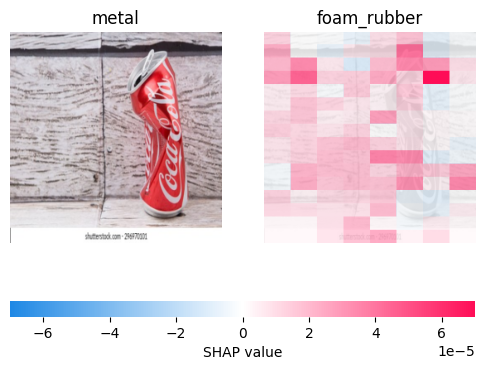

Explanation for test sample 4 (True Class: foam_rubber)
Predicted Class: foam_rubber


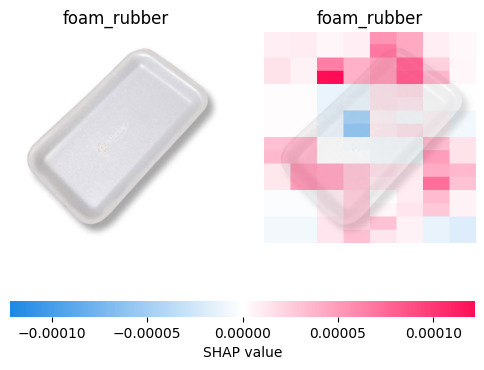

Explanation for test sample 5 (True Class: cardboard)
Predicted Class: cardboard


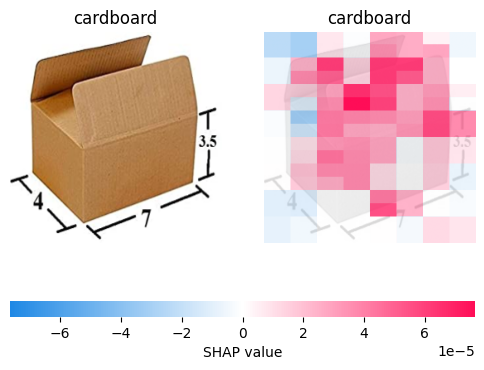

In [20]:
import shap
from PIL import Image # Ensure Image is imported
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import timm
import numpy as np
import os
from tqdm import tqdm

# Ensure the model and feature extractor are on the correct device
feature_extractor.to(device)
feature_extractor.eval()

# Define normalize transform globally for use in predict_proba_shap and the visualization loop
normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

# 1. Define the prediction function for SHAP
def predict_proba_shap(images_numpy):
    # images_numpy will be a numpy array from SHAP. Convert to tensor.
    # SHAP expects (N, H, W, C), PyTorch needs (N, C, H, W)
    images_tensor = torch.from_numpy(images_numpy).float().permute(0, 3, 1, 2)

    # Apply normalization (assuming it was part of data_transforms originally)
    # For this demonstration, we'll assume the input `images_numpy` to `predict_proba_shap`
    # already has the correct pixel values (e.g., 0-1 range) but still needs normalization.
    images_tensor = normalize(images_tensor / 255.0) # Normalize images from 0-255 range to 0-1 before applying mean/std

    with torch.no_grad():
        images_tensor = images_tensor.to(device)
        features = feature_extractor(images_tensor)

    # Convert features to DMatrix for XGBoost prediction
    d_features = xgb.DMatrix(features.cpu().numpy())

    # Get probabilities from XGBoost model
    probabilities = model.predict(d_features)
    return probabilities

# 2. Select background data for KernelExplainer
# For image data, SHAP often uses a small subset of training images or a blurred version
# to represent the background. We need raw images for the prediction function.

# Get a few background images from the training set (e.g., 50 random samples)
num_background_samples = 50
sampled_indices = np.random.choice(len(train_dataset), num_background_samples, replace=False)
background_images_list = []
for i in sampled_indices:
    # Get the raw image path and label from the dataset
    pil_image_path, _ = train_dataset.samples[i]
    # Open the image using PIL
    pil_image_obj = Image.open(pil_image_path).convert('RGB')

    # Apply the initial Resize to the PIL image
    resized_image = transforms.Resize((256, 256))(pil_image_obj)

    # Convert to numpy array (H, W, C) for SHAP background
    # SHAP's KernelExplainer expects (N, H, W, C) for image inputs
    background_images_list.append(np.array(resized_image))

background_images_numpy = np.array(background_images_list)

print(f"Shape of background images for SHAP: {background_images_numpy.shape}")

# Initialize Explainer with an explicit image masker
# Pass one of the background images to the masker to define its shape
masker = shap.maskers.Image(background_images_numpy[0])
explainer = shap.Explainer(predict_proba_shap, masker=masker)

# 3. Select samples for explanation from the test set (e.g., 5 random samples)
num_explanation_samples = 5
sampled_test_indices = np.random.choice(len(test_dataset), num_explanation_samples, replace=False)

explanation_images_list = []
explanation_labels_list = []
for i in sampled_test_indices:
    pil_image_path, label = test_dataset.samples[i]
    pil_image_obj = Image.open(pil_image_path).convert('RGB')
    resized_image = transforms.Resize((256, 256))(pil_image_obj)
    explanation_images_list.append(np.array(resized_image))
    explanation_labels_list.append(label)

explanation_images_numpy = np.array(explanation_images_list)

print(f"Shape of explanation images for SHAP: {explanation_images_numpy.shape}")
print("Calculating SHAP values... This may take a while.")

# Compute SHAP values
# Instead of explainer.shap_values(), call the explainer object directly
shap_explanation = explainer(explanation_images_numpy)
shap_values = shap_explanation.values # Access the values from the Explanation object

print("SHAP values calculated.")

# Get class names for plotting
class_names = test_dataset.classes

# Visualize SHAP explanations
print("\nVisualizing SHAP explanations:")
for i in range(num_explanation_samples):
    print(f"Explanation for test sample {i+1} (True Class: {class_names[explanation_labels_list[i]]})")
    # Use the `idx` parameter to specify which class to explain for a multi-output model
    # For multi-class, shap.image_plot usually shows explanations for all classes by default
    # or allows specifying a class index. Here, we'll plot for the predicted class.

    # Predict the class for this specific image to plot SHAP values for it
    image_path_for_prediction = test_dataset.samples[sampled_test_indices[i]][0]
    pil_image_for_prediction = Image.open(image_path_for_prediction).convert('RGB')
    single_image_tensor = normalize(transforms.ToTensor()(transforms.Resize((256,256))(pil_image_for_prediction))).unsqueeze(0).to(device)
    single_feature = feature_extractor(single_image_tensor)
    single_d_feature = xgb.DMatrix(single_feature.cpu().numpy())
    predicted_proba = model.predict(single_d_feature)
    predicted_class_idx = np.argmax(predicted_proba)
    predicted_class_name = class_names[predicted_class_idx]

    print(f"Predicted Class: {predicted_class_name}")

    # shap.image_plot expects images in (N, H, W, C) format
    # It expects shap_values as a list of arrays, one for each output class
    # And the original image in (H, W, C) format
    shap.image_plot(
        shap_values[i:i+1, :, :, :, predicted_class_idx],
        explanation_images_numpy[i:i+1],
        labels=[predicted_class_name],
        true_labels=[class_names[explanation_labels_list[i]]]
    )